# Sales Data Visualization

This notebook demonstrates **data visualization with matplotlib** using a simple sales dataset.

Charts included:
1. Bar chart — revenue by category
2. Pie chart — category share
3. Horizontal bar chart — revenue per item

In [10]:
from dataclasses import dataclass


@dataclass(frozen=True)
class Sale:
    item: str
    category: str
    price: int
    quantity: int

    @property
    def revenue(self) -> int:
        return self.price * self.quantity


sales = [
    Sale(item="Apple",   category="Fruit",     price=120, quantity=4),
    Sale(item="Banana",  category="Fruit",     price=80,  quantity=6),
    Sale(item="Orange",  category="Fruit",     price=100, quantity=5),
    Sale(item="Carrot",  category="Vegetable", price=60,  quantity=5),
    Sale(item="Tomato",  category="Vegetable", price=150, quantity=3),
    Sale(item="Spinach", category="Vegetable", price=90,  quantity=4),
    Sale(item="Milk",    category="Dairy",     price=200, quantity=3),
    Sale(item="Cheese",  category="Dairy",     price=350, quantity=2),
]

# Summarise by category
category_totals: dict[str, int] = {}
for s in sales:
    category_totals[s.category] = category_totals.get(s.category, 0) + s.revenue

grand_total = sum(s.revenue for s in sales)
print(f"Grand total: {grand_total} yen")
category_totals

Grand total: 3870 yen


{'Fruit': 1460, 'Vegetable': 1110, 'Dairy': 1300}

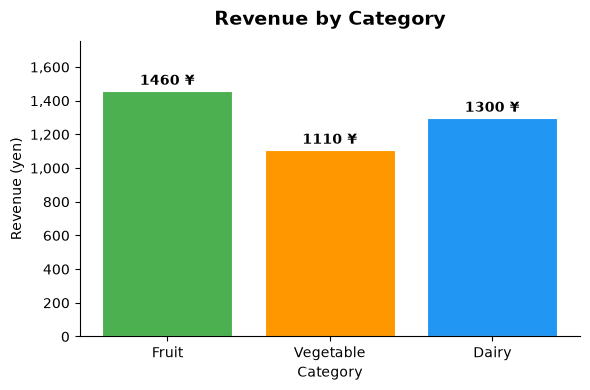

In [11]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# Shared colour palette — one colour per category
PALETTE = {
    "Fruit":     "#4CAF50",
    "Vegetable": "#FF9800",
    "Dairy":     "#2196F3",
}

categories = list(category_totals.keys())
amounts    = list(category_totals.values())
colors     = [PALETTE.get(c, "#9E9E9E") for c in categories]

# ── 1. Bar chart: revenue by category ──────────────────────────────────────
fig, ax = plt.subplots(figsize=(6, 4))

bars = ax.bar(categories, amounts, color=colors, edgecolor="white", linewidth=0.8)

# Value labels on top of each bar
for bar, amount in zip(bars, amounts):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 15,
        f"{amount} ¥",
        ha="center", va="bottom", fontsize=10, fontweight="bold"
    )

ax.set_title("Revenue by Category", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Category")
ax.set_ylabel("Revenue (yen)")
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.set_ylim(0, max(amounts) * 1.2)
ax.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

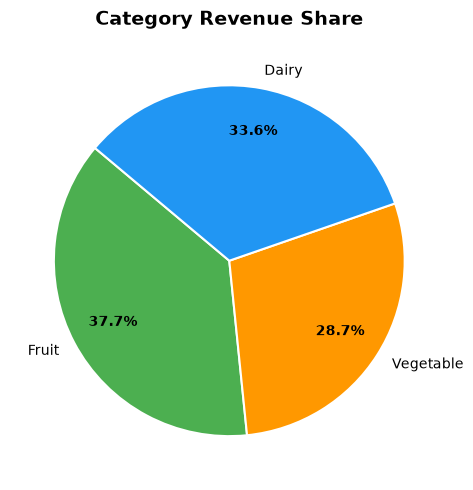

In [12]:
# ── 2. Pie chart: category share ────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(5, 5))

wedges, texts, autotexts = ax.pie(
    amounts,
    labels=categories,
    colors=colors,
    autopct="%1.1f%%",
    startangle=140,
    pctdistance=0.75,
    wedgeprops={"edgecolor": "white", "linewidth": 1.5},
)

for at in autotexts:
    at.set_fontsize(10)
    at.set_fontweight("bold")

ax.set_title("Category Revenue Share", fontsize=14, fontweight="bold", pad=12)

plt.tight_layout()
plt.show()

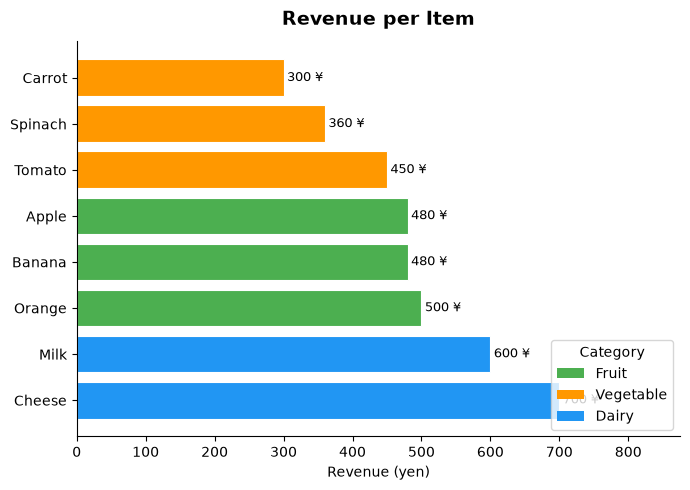

In [13]:
# ── 3. Horizontal bar chart: revenue per item ───────────────────────────────
items    = [s.item for s in sales]
revenues = [s.revenue for s in sales]
item_colors = [PALETTE.get(s.category, "#9E9E9E") for s in sales]

# Sort by revenue descending
sorted_pairs = sorted(zip(revenues, items, item_colors), reverse=True)
revenues_s, items_s, colors_s = zip(*sorted_pairs)

fig, ax = plt.subplots(figsize=(7, 5))

hbars = ax.barh(items_s, revenues_s, color=colors_s, edgecolor="white", linewidth=0.8)

# Value labels at end of each bar
for bar, rev in zip(hbars, revenues_s):
    ax.text(
        bar.get_width() + 5,
        bar.get_y() + bar.get_height() / 2,
        f"{rev} ¥",
        va="center", fontsize=9
    )

ax.set_title("Revenue per Item", fontsize=14, fontweight="bold", pad=12)
ax.set_xlabel("Revenue (yen)")
ax.set_xlim(0, max(revenues_s) * 1.25)
ax.spines[["top", "right"]].set_visible(False)

# Add a legend for categories
from matplotlib.patches import Patch
legend_handles = [Patch(facecolor=color, label=cat) for cat, color in PALETTE.items()]
ax.legend(handles=legend_handles, title="Category", loc="lower right")

plt.tight_layout()
plt.show()